# Projeto de Engenharia de Atributos

#### Neste projeto trabalharemos em atividades de engenharia de atributos em um cenário onde a precisão é requisito mandatório: dados médicos.

`Readmissões   hospitalares (quando   um   paciente   recebe   alta   mas   é   internado novamente pouco tempo depois) são caras e refletem as inadequações no sistema de saúde.`

Nos  Estados  Unidos  sozinho,  o  tratamento  de  pacientes  diabéticos  readmitidos  excede 300 milhões de dólares por ano. Identificação precoce de pacientes que enfrentam um alto risco de readmissão pode permitir que os profissionais de saúde conduzam investigações adicionais e possivelmente   impeçam   futuras   readmissões.   Isso   não   apenas   melhora   a   qualidade   do atendimento, mas também reduz as despesas médicas em readmissão.

Diabetes é a sétima principal causa de morte (dados de 2016, fonte ao final do texto) no mundo  e  afeta  cerca  de  23,6  milhões  de  pessoas  só  nos  EUA  e  milhões  de  pessoas  são diagnosticadas com diabetes a cada ano em todo mundo.

Segundo  a  Associação  Americana  de  Diabetes,  o  custo  do  atendimento  a  pacientes diabéticos e pré-diabéticos nos Estados Unidos é o maior do mundo. Essa epidemia global afeta mais  de  350  milhões  de  pessoas,  com  3  milhões  de  pessoas  morrendoa  cada  ano  devido  a complicações relacionadas ao diabetes, predominantemente cardiovasculares ou nefropáticas.

`A readmissão hospitalar é uma das principais preocupações no tratamento do diabetes, com milhões de dólares sendo gastos no tratamento de pacientes diabéticos que precisam ser readmitidos em um hospital após receberem alta.`

*`A  necessidade  de  readmissão  indica  que  cuidados  inadequados  foram  fornecidos  ao paciente  no  momento  da  primeira  admissão.`*  `A  taxa  de  readmissão  se  tornou  uma  métrica importante para medir a qualidade geral de um hospital.`

***Como analista de dados principal da organização (hospital, clínica ou operadora de plano de  saúde),  o  trabalho  é  identificar  os  pacientes  diabéticos  de  alto  risco  por  meio  de estratificação de risco de registros médicos eletrônicos. Usaremos registros eletrônicos de dados médicos, como resultados dos exames, nível de insulina, diagnóstico de outras doenças, etc...***

### Fonde dos dados:

**Usaremos o conjunto de dados, "Diabetes 130-US hospitals for years 1999-2008", quefoi baixado do UCI Machine Learning Repository**
>http://archive.ics.uci.edu/ml/datasets/diabetes+130-us+hospitals+for+years+1999-2008

*Os dados representam 10 anos (1999-2008) de atendimento clínico em 130 hospitais dos EUA e redes de distribuição integradas com 100.000 observações e 50 recursos (variáveis) que representam  os  registros  eletrônicos com  resultados  de  exames  dos  pacientes  e  dados  sobre cada hospital.*

In [1]:
# Imports

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Carregando os dados

dados = pd.read_csv("diabetic_data.csv")

In [3]:
dados.shape

(101766, 50)

In [4]:
# Amostra dos dados

dados.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

**Somente as variáveis: max_glu_serum, A1Cresult possuem valores nulos**

### *Dicionário de Dados*

**0**-encounter_id-identificador único de um encontro do pesquisador com o paciente.

**1**-patient_nbr-identificador exclusivo de um paciente.

**2**-race-valores: Caucasian, Asian, African American, Hispanic e other.

**3**-gender-valores: male, female, and unknown/invalid.

**4**-age-agrupados em intervalos de 10 anos: (0, 10), (10, 20), ..., (90, 100).

**5**-weight-peso em libras.

**6**-admission_type_id -identificador inteiro correspondente a 9 valores distintos, por exemplo, "emergência, urgência, eletiva, recém-nascido e não disponível".

**7**-discharge_disposition_id-identificador inteiro correspondente a 29 valores distintos, por exemplo, "enviado para casa, expirou e não está disponível".

**8**-admission_source_id-identificador inteiro correspondente a 21 valores distintos, por exemplo, "encaminhamento médico, e transferência de um hospital".

**9**-time_in_hospital-número inteiro dedias entre a admissão e a alta,

**10**-payer_code-identificador  inteiro  correspondente  a  23  valores  distintos,  por exemplo, Blue Cross / Blue Shield, Medicare e auto-pagamento".

**11**-medical_specialty-identificador inteiro de uma especialidade do médico admitidor, correspondente  a  84  valores  distintos,  por  exemplo,  cardiologia,  medicina  interna,  família  / clínica geral e cirurgião".

**12**-num_lab_procedures-número  de  testes  de  laboratório  realizados  durante  a consulta.

**13**-num_procedures-número  de  procedimentos  (exceto  testes  de  laboratório) realizados durante a consulta.

**14**-num_medications-número  de  medicamentos  genéricos  distintos  administrados durante a consulta.

**1**5-number_outpatient-número de consultas ambulatoriais do paciente no ano anterior aconsulta.

**16**-number_emergency-número de visitas de emergência do paciente no ano anterior a consulta.

**17**-number_inpatient-número de visitas hospitalares do paciente no ano anterior a consulta.

**18**-diag_1-diagnóstico primário (codificado como três primeiros dígitos da CID9); 848 valores distintos.

**19**-diag_2-diagnóstico secundário (codificado como três primeiros dígitos da CID9); 923 valores distintos.

**20**-diag_3-diagnóstico secundário adicional (codificado como três primeiros dígitos da CID9); 954 valores distintos.

**21**-number_diagnoses-número de diagnósticos inseridos no sistema.

**22**-max_glu_serum-teste sérico de glicose que indica a faixa do resultado ou se o teste não foi realizado. Valores: > 200, > 300, normal e nenhum, se não for medido.

**23**-A1Cresult-teste  A1c  que  indica  o  intervalo  do  resultado  ou  se  o  teste  não  foi realizado. Valores: > 8 (se o resultado for maior que 8%), > 7 (se o resultado for maior que 7%, porém menor que 8%), normal (se o resultado for inferior a 7%) e nenhum,se não for medido.

***Na sequência temos os recursos de 24 a 46 para os nomes dos medicamentos genéricos:***
>Cada  um  desses  recursos  indica  se  o  medicamento  foi  prescrito  ou  sehouve  uma alteração na dosagem. Valores: "up" se a dose foi aumentada durante a consulta

**metformina,  repaglinida,  nateglinida,  clorpropamida,  glimepirida,  acetohexamida, glipizida, gliburida, tolbutamida, pioglitazona, rosiglitazona, acarbose, miglitol, troglitazona, insulazforamida,  examide,  sitaglagliptida,  sitazagliptida  ,  glipizida-metformina,  glimepirida-pioglitazona, metformina-rosiglitazona e metformina-pioglitazona**


**47**-change-indica se houve alteração nos medicamentos para diabéticos (dosagem ou nome genérico). Valores: "change" e "no change".

**48**-diabetesMed-indica  se  houve  algum  medicamento  diabético  prescrito.  Valores: "sim" e "não".

**49**-readmitted-readmitido,  "Dias  para  readmissão  hospitalar.  Valores:  <30  (se  o paciente foi readmitido em menos de 30 dias), > 30 (se o paciente foi readmitido em mais de 30 dias) e No, para nenhum registro de readmissão.

---------------

### Limpesa e Transformação

In [6]:
# Verificando valores nulos (ausentes)

dados.isna().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [7]:
# Checando as colunas que tem valor = '?'

dados.isin(['?']).sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [8]:
for col in dados:
    
    unicos = dados[col].nunique() # conta os valores unicos

    print(f'\n {col} {unicos} valores únicos')
    
    if unicos < 15:
               
        print(dados[col].unique()) # retorna os valores unicos


 encounter_id 101766 valores únicos

 patient_nbr 71518 valores únicos

 race 6 valores únicos
['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']

 gender 3 valores únicos
['Female' 'Male' 'Unknown/Invalid']

 age 10 valores únicos
['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']

 weight 10 valores únicos
['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']

 admission_type_id 8 valores únicos
[6 1 2 3 4 5 8 7]

 discharge_disposition_id 26 valores únicos

 admission_source_id 17 valores únicos

 time_in_hospital 14 valores únicos
[ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]

 payer_code 18 valores únicos

 medical_specialty 73 valores únicos

 num_lab_procedures 118 valores únicos

 num_procedures 7 valores únicos
[0 5 1 6 2 3 4]

 num_medications 75 valores únicos

 number_outpatient 39 valores únicos

 number_emergency 33 valores únicos

 number_inpatient 21 valores ún

**O caracter '?' nada mais é do que valor ausente. Vamos limpar isso!**

In [9]:
for col in dados.select_dtypes(include='object'): #Percorre apenas colunas do tipo texto (object), evita colunas numéricas
    
    total = (dados[col] == '?').sum() # Conta quantos '?' existem na coluna.
    
    if total > 0: # Se '? 'for maior do que 0
        
        percent = (total / len(dados) * 100).round(2)
        #percent = round(total / dados.shape[0] * 100, 2)
        
        print(f"\nA Coluna {col} tem {total} valores '?'")
        print(f"Isso representa {percent}% do total")



A Coluna race tem 2273 valores '?'
Isso representa 2.23% do total

A Coluna weight tem 98569 valores '?'
Isso representa 96.86% do total

A Coluna payer_code tem 40256 valores '?'
Isso representa 39.56% do total

A Coluna medical_specialty tem 49949 valores '?'
Isso representa 49.08% do total

A Coluna diag_1 tem 21 valores '?'
Isso representa 0.02% do total

A Coluna diag_2 tem 358 valores '?'
Isso representa 0.35% do total

A Coluna diag_3 tem 1423 valores '?'
Isso representa 1.4% do total


#### A Coluna "Gender" possue 3 valores 'Unknown/Invalid' = 0.0%

In [10]:
# A coluna gender também apresenta um valor que precisamos tratar = 'Unknown/Invalid'

dados['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [11]:
percentual = (dados['gender'] == 'Unknown/Invalid').sum()/100
percentual.round()

np.float64(0.0)

**Agora a parte importante - decidir o que fazer!**

- Falta os dados sobre peso(weight) do paciente em mais de 96% dos registros. 

- O código do pagador(payer_code) e a especialidade médica também apresentam valores ausentes de 40 a 50%. 

- *As demais variáveis apresentam um baixo percentual de valores ausentes.*

**O que fazer?**

#### **Alternativas:**

- Colocar a variável `peso(weight)` como categórica com dois labels: *disponível / não disponível (1 e 0).*
- Criar um código genérico para a variável `payer_code` como *99* e preencher os valores ausentes.
- Criar um tipo genérico para a `variável medical_specialty` como *'Sem Especialidade Definida'* e preencher os valores ausentes.
- Para a variável `gender` são apenas 3 registros e o ideal é *removê-los.*

#### **Decisão:**

- 1- Devido à fraca interpretabilidade dos valores ausentes da variável peso, o melhor é simplesmente ignorar a variável e removê-la.

- 2- Vamos descartar as variáveis payer_code e medical_specialty, pois seria difícil tratar quantidade muito grande de valores ausentes.

- 3- Vamos remover os registros com "?" das demais variáveis.

- 4- Para a variável gender vamos remover os 3 registros com categoria "Unknown/Invalid".

#### Removendo as 3 colunas com alto percentual de valores ausentes:

In [12]:
# Removendo as 3 colunas com alto percentual de valores ausentes

dados = dados.drop(['weight', 'payer_code', 'medical_specialty'], axis = 1)

*Removemos os registros com baixo percentual de valores ausentes*

In [13]:
# Removemos os registros com baixo percentual de valores ausentes (! = diferente)

dados = dados[dados['race'] != '?']
dados = dados[dados['diag_1'] != '?']
dados = dados[dados['diag_2'] != '?']
dados = dados[dados['diag_3'] != '?']
dados = dados[dados['gender'] != 'Unknown/Invalid']

**Verificando se ainda tem dados "!"**

In [14]:
dados.isin(['!']).sum()
#dados.isin(['!']).any()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol  

In [15]:
dados.shape

(98052, 47)

In [16]:
# Visualizando os dados

dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,Steady,No,No,No,No,No,No,Yes,>30


**Será que temos variáveis com um único valor?**

In [17]:
# Checando por variáveis com um único valor

#dados.loc[:, dados.nunique() == 1] # Retorna um dataframe

dados.nunique()[dados.nunique() == 1] # Retorna as colunas e quantidade

examide                    1
citoglipton                1
metformin-rosiglitazone    1
dtype: int64

*Possuimos 3 colunas com todas as linhas preenchidas com o mesmo valor!*

**Vamos eliminar as colunas que têm apenas 1 valor único, pois elas não adicionam nada à nossa análise.**

In [18]:
# Removendoo variáveis com valores únicos
# Seleciona todas as linhas .loc[:, ...] e apenas as colunas que não têm apenas um único valor .nunique() != 1

dados = dados.loc[:, dados.nunique() != 1]

In [19]:
dados.shape

(98052, 44)

#### Engenharia de Atributos

**Ajustando a Variável Alvo Para Estratificação de Risco**

Uma readmissão hospitalar ocorre quando um paciente que recebe alta do hospital é readmitido novamente dentro de um certo período de tempo. As taxas de readmissão hospitalar para certas condições agora são consideradas um indicador da qualidade do hospital e também afetam negativamente o custo médico.

**Nossa variável alvo é 'readmiited'. Queremos saber se um paciente será readmitido no hospital ou não.**

* A variável possui os valores:

-- < 30 (readmissão em menos de 30 dias)

-- > 30 (readmissão em mais de 30 dias)

-- No (sem readmissão)

Nós podemos combinar a readmissão antes de 30 dias e após 30 dias em uma categoria (VALOR 1 - classe positiva) e nenhuma readmissão em outra categoria (VALOR 0 - classe negativa) para tornar nosso problema classificação binária.

In [20]:
dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,Up,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,Up,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,Steady,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,No,Steady,No,No,No,No,No,Yes,>30


In [21]:
# Verificando os Valores Únicos e a Quantidade

dados['readmitted'].value_counts()

readmitted
NO     52337
>30    34649
<30    11066
Name: count, dtype: int64

In [22]:
# Primeiro, vamos criar uma cópia do dataset até aqui!!!
dados_clean = dados

# Se precisar voltar a este ponto, apenas executamos:
# dados = dados_clean

# Assim não teremos que executar todo jupyter notebook até aqui

In [23]:
# Ajustando a variável alvo

# '0' significa que não foi readmitido
# '1' significa que foi readmitido, não importa quantos dias após a alta

dados['readmitted'] = dados['readmitted'].replace('>30', 1)
dados['readmitted'] = dados['readmitted'].replace('<30', 1)
dados['readmitted'] = dados['readmitted'].replace('NO', 0)

In [24]:
# Verifica os valores únicos

#dados['readmitted'].unique()
dados['readmitted'].value_counts()

readmitted
0    52337
1    45715
Name: count, dtype: int64

In [25]:
# Checando o tipo de dado

dados['readmitted'].dtype

dtype('int64')

In [26]:
dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,Up,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,Up,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,Steady,No,No,No,No,Ch,Yes,0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,No,Steady,No,No,No,No,No,Yes,1


In [27]:
# Verifica a proporção de cada classe

#round(dados.readmitted.value_counts() / len(dados.index) * 100, 0)
round(dados.readmitted.value_counts(normalize=True) * 100, 0)

# normalize=True → já retorna a proporção (0 a 1)

readmitted
0    53.0
1    47.0
Name: proportion, dtype: float64

#### Gráfico:
Percentual de cada valor da variável alvo

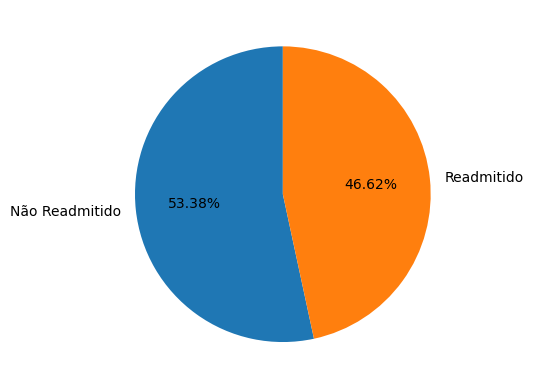

In [28]:
plt.pie(
    dados['readmitted'].value_counts(normalize=True),
    labels=['Não Readmitido', 'Readmitido'],
    autopct='%1.2f%%',
    startangle=90
)
plt.show()

#### Recategorização de Variável
Tratamos a variável idade

In [29]:
# Tipo da variável (O) = Object

dados.age.dtype

dtype('O')

In [30]:
# Total de pacientes por faixa etária

#dados.groupby('age').size()

dados['age'].value_counts()

age
[70-80)     25305
[60-70)     21809
[80-90)     16702
[50-60)     16697
[40-50)      9265
[30-40)      3548
[90-100)     2717
[20-30)      1478
[10-20)       466
[0-10)         65
Name: count, dtype: int64

Text(0, 0.5, 'Count')

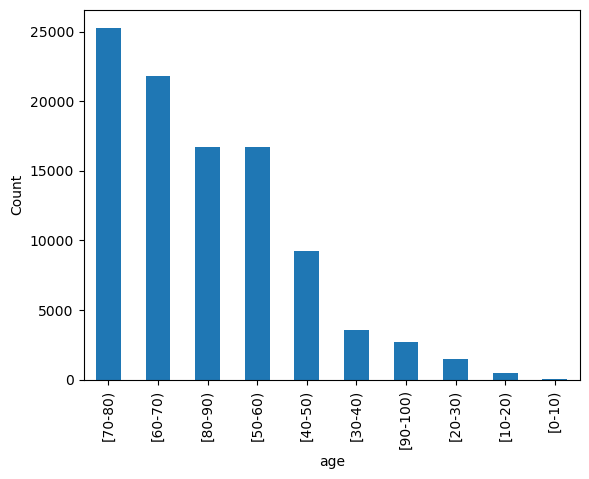

In [31]:
# Vamos verificar a variável que representa a faixa etária dos pacientes

dados['age'].value_counts().plot(kind = 'bar')
plt.ylabel('Count')

`Podemos perceber que a maioria dos pacientes está na faixa entre 50 e 90 anos.`

Existem diferentes maneiras de lidar com essa variável. O conjunto de dados nos dá a idade apenas como categorias nas faixas de 10 anos, portanto, não sabemos a idade exata de cada paciente. 

Podemos adotar duas abordagens:

- 1- Se queremos ver o efeito do aumento da idade na readmissão do paciente, mesmo que de maneira grosseira, podemos assumir que a idade do paciente, em média, esteja no ponto médio da categoria de idade. Por exemplo, se a categoria de idade do paciente é de 20 a 30 anos, assumimos a idade = 25 anos. Então, convertemos categorias de idade em pontos médios, resultando em uma variável numérica.


- 2- Podemos recategorizar a variável, distribuindo os pacientes por um número menor de faixas e manter a variável como categórica. Nesse caso, poderíamos avaliar o risco por faixa etária e não por idade.

**Adotaremos a opção 2 pois altera menos a informação contida nos dados.**

In [32]:
# Recategorizamos 'idade' para que a população seja distribuída de maneira mais uniforme

# Classificamos como faixa de 0-50 pacientes de até 50 anos

dados['age'] = dados['age'].replace(['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)'], '[0-50)')

In [33]:
# Acima de 80 anos ficam na faixa de 80-100
# As outras faixas são mantidas

dados['age'] = dados['age'].replace(['[80-90)', '[90-100)'],'[80-100)')

In [34]:
# Tipo ds variável

dados.age.dtype

dtype('O')

Text(0, 0.5, 'Count')

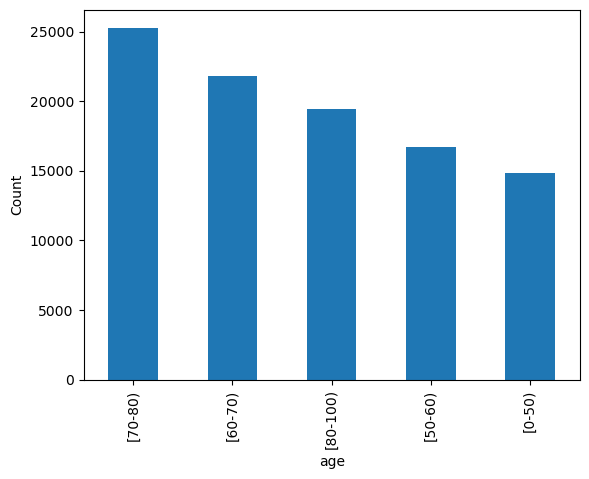

In [35]:
# Vamos verificar a variável que representa a faixa etária dos pacientes

dados.age.value_counts().plot(kind = 'bar')
plt.ylabel('Count')

* Uma análise mais detalhada do arquivo **IDs_mapping.csv** revelará que `'admission_type_id', 'harge_disposition_id' e 'admission_source_id' têm valores com significado semelhante. Eles podem ser mesclados para ter menos valores.`

In [36]:
# Visualizando os dados
dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[0-50),1,1,7,3,59,...,No,No,Up,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[0-50),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[0-50),1,1,7,2,44,...,No,No,Up,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[0-50),1,1,7,1,51,...,No,No,Steady,No,No,No,No,Ch,Yes,0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,No,Steady,No,No,No,No,No,Yes,1


#### 1. Variável **admission_type_id**

In [37]:
dados.admission_type_id.unique()
#dados.admission_type_id.value_counts()

# possue 8 niveis ()valores unicos e iremos reduzir para 2

array([1, 2, 3, 6, 4, 5, 8, 7])

In [38]:
# Quantidade de Valores unicos

dados.admission_type_id.nunique()

8

In [39]:
# A variável 'admission_type_id' contém 8 níveis
# Reduziremos os níveis de 'admission_type_id' para duas categorias

dados['admission_type_id'] = dados['admission_type_id'].map({1: 'Emergencia'}).fillna('Outro')

# dados['admission_type_id'] = np.where(dados['admission_type_id'] == 1, 'Emergencia', 'Outro')

# dados['admission_type_id'] = dados['admission_type_id'].replace(1, 'Emergencia')
# dados['admission_type_id'] = dados['admission_type_id'].replace([2,3,4,5,6,7,8], 'Outro')

In [40]:
# quantidade de valores unicos

dados.admission_type_id.nunique()

2

In [41]:
dados.admission_type_id.value_counts()

admission_type_id
Emergencia    52178
Outro         45874
Name: count, dtype: int64

In [42]:
dados.admission_type_id.unique()

array(['Emergencia', 'Outro'], dtype=object)

#### 2. Variável **discharge_disposition_id**



In [43]:
# motra quais são os valores unicos

dados.discharge_disposition_id.unique()

array([ 1,  3,  6,  2,  5, 11,  7, 25, 10,  4, 14, 18,  8, 13, 12, 16, 17,
       22, 23,  9, 20, 15, 24, 28, 19, 27])

In [44]:
# Total de valores unicos por categoria

dados.discharge_disposition_id.value_counts()

discharge_disposition_id
1     57609
3     13564
6     12626
18     3624
2      2049
22     1970
11     1606
5      1127
25      941
4       756
7       592
23      400
13      396
14      368
28      137
8       106
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

In [45]:
# Quantidade de valores unicos

dados.discharge_disposition_id.nunique()

26

In [46]:
# A variável 'discharge_disposition_id' contém 26 níveis
# Reduziremos os níveis de 'discharge_disposition_id' para duas categorias

dados['discharge_disposition_id'] = (dados['discharge_disposition_id'].map({1: 'Casa'}).fillna('Outro'))

#dados['discharge_disposition_id'] = np.where(dados['discharge_disposition_id'] == 1,'Casa','Outro')

In [47]:
# Quantidade de valores unicos

dados.discharge_disposition_id.nunique()

2

In [48]:
# Total de valores unicos por categoria

dados.discharge_disposition_id.value_counts()

discharge_disposition_id
Casa     57609
Outro    40443
Name: count, dtype: int64

#### 3. Variável **admission_source_id**

In [49]:
dados.admission_source_id.unique()

array([ 7,  2,  4,  1,  5,  6, 20,  3, 17,  8,  9, 14, 10, 22, 11, 25, 13])

In [50]:
dados.admission_source_id.nunique()

17

In [51]:
dados.admission_source_id.value_counts()

admission_source_id
7     55951
1     28355
17     6602
4      2945
6      1893
2      1031
5       846
3       179
20      160
9        49
8        15
22       12
10        7
14        2
11        2
25        2
13        1
Name: count, dtype: int64

In [52]:
# A variável 'admission_source_id' contém 17 níveis
# # Reduziremos os níveis de 'admission_source_id' para três categorias

dados['admission_source_id'] = (dados['admission_source_id'].map({7: 'Sala_Emergencia', 1: 'Recomendacao'}).fillna('Outro'))

In [53]:
dados.admission_source_id.nunique()

3

In [54]:
dados.admission_source_id.value_counts()

admission_source_id
Sala_Emergencia    55951
Recomendacao       28355
Outro              13746
Name: count, dtype: int64

>O conjunto de dados contém até três diagnósticos para um determinado paciente (primário, secundário e adicional). 
>
>No entanto, cada um deles tem códigos ICD-9 exclusivos e é extremamente difícil incluí-los no modelo e interpretar de forma significativa. 
>
>Portanto, reduziremos esses códigos de diagnóstico para 4 categorias.
>
>Códigos ICD-9 (International Classification of Diseases ou Código Internacional de Doenças):

https://en.wikipedia.org/wiki/List_of_ICD-9_codes

http://www.icd9data.com/2013/Volume1/default.htm

https://icd.codes/icd9cm

https://www.cms.gov/Medicare/Coding/ICD9ProviderDiagnosticCodes/codes

In [55]:
# Concatena 3 variáveis em um dataframe

diagnostico = dados[['diag_1', 'diag_2', 'diag_3']]

In [56]:
diagnostico.head(10)

,diag_1,diag_2,diag_3
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486
10,250.7,403,996


In [57]:
diagnostico.isna().sum()

diag_1    0
diag_2    0
diag_3    0
dtype: int64

---

**Variáveis de Dosagem de Medicamentos e Agrupamento de Variáveis:**

In [58]:
# Verificando nosso conjunto de dados até aqui:

dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,No,No,Up,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,No,No,Up,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,No,No,Steady,No,No,No,No,Ch,Yes,0
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,No,No,Steady,No,No,No,No,No,Yes,1


O conjunto de dados contém 23 recursos para 23 medicamentos que indicam, para cada um deles, se uma alteração no medicamento foi feita ou não durante a atual internação do paciente.

**Vamos plotar algumas variáveis que indicam uso de medicamento:**

Text(0, 0.5, 'Count')

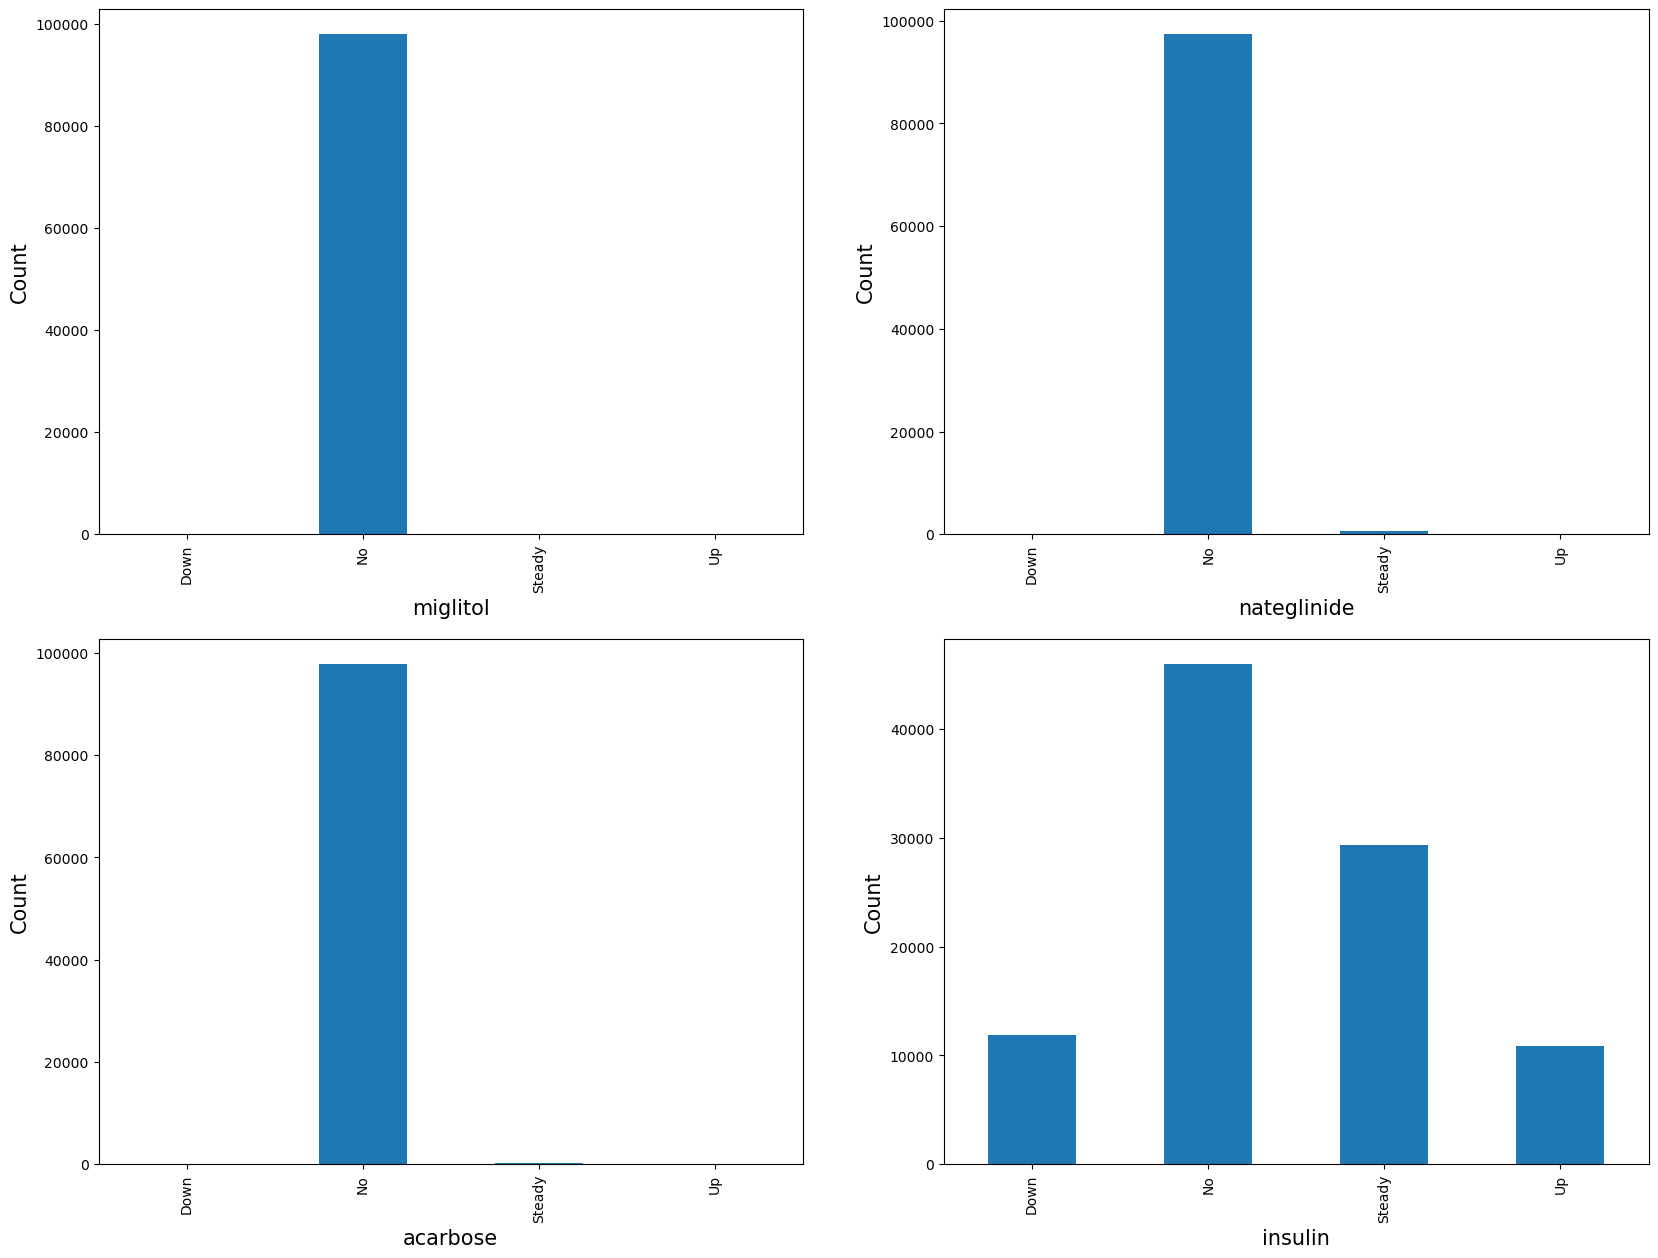

In [59]:
# Plot
fig = plt.figure(figsize = (20,15))

ax1 = fig.add_subplot(221)
ax1 = dados.groupby('miglitol').size().plot(kind = 'bar')
plt.xlabel('miglitol', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

ax2 = fig.add_subplot(222)
ax2 = dados.groupby('nateglinide').size().plot(kind = 'bar')
plt.xlabel('nateglinide', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

ax3 = fig.add_subplot(223)
ax3 = dados.groupby('acarbose').size().plot(kind = 'bar')
plt.xlabel('acarbose', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

ax4 = fig.add_subplot(224)
ax4 = dados.groupby('insulin').size().plot(kind = 'bar')
plt.xlabel('insulin', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

Podemos contar quantas alterações foram feitas no total para cada paciente e criamos um novo atributo. Isso pode ajudar a descobrir uma relação com o número de alterações, independentemente de qual medicamento foi alterado.

Além disso, podemos criar um novo atributo indicando o total de medicamentos que cada paciente consumiu durante a internação. E então avaliamos se há relação do total com a readmissão.

In [60]:
# Shape
dados.shape

(98052, 44)

In [61]:
dados.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted'],
      dtype='object')

In [62]:
# Lista com os nomes das variáveis de medicamentos

medicamentos = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 
                'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 
                'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 
                'glimepiride-pioglitazone', 'metformin-pioglitazone']

In [63]:
# Loop para ajustar o valor das variáveis

cols = dados.columns.intersection(medicamentos)

dados[cols + 'temp'] = (~dados[cols].isin(['No','Steady'])).astype(int)

In [64]:
# Cria uma variável para receber a contagem por paciente
dados['num_alt_dosagem_med'] = 0

In [65]:
# Contagem de modificações na dosagem de medicamentos

for col in medicamentos:
    if col in dados.columns:
        colname = str(col) + 'temp'
        dados['num_alt_dosagem_med'] = dados['num_alt_dosagem_med'] + dados[colname]
        del dados[colname]

In [66]:
# Verifica o total por modificações na dosagem de medicamentos
dados.num_alt_dosagem_med.value_counts()

num_alt_dosagem_med
0    71309
1    25350
2     1281
3      107
4        5
Name: count, dtype: int64

In [67]:
dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,num_alt_dosagem_med
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,No,Up,No,No,No,No,Ch,Yes,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,No,No,No,No,No,No,No,Yes,0,0
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,No,Up,No,No,No,No,Ch,Yes,0,1
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,No,Steady,No,No,No,No,Ch,Yes,0,0
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,No,Steady,No,No,No,No,No,Yes,1,0


**Vamos alterar o valor das colunas dos medicamentos para refletir se esse medicamento está sendo administrado a um paciente ou não.**

In [68]:
# Recoding das colunas de medicamentos

cols = dados.columns.intersection(medicamentos)

dados[cols] = dados[cols].replace({'No':0,'Steady':1,'Up':1,'Down':1})

**Agora, criamos mais uma coluna para refletir quantos medicamentos estão sendo administrados a um paciente.**

In [69]:
# Variável com a contagem de medicamentos por paciente
dados['num_med'] = 0

In [70]:
# Carregamos a nova variável
for col in medicamentos:
    if col in dados.columns:
        dados['num_med'] = dados['num_med'] + dados[col]

In [71]:
# Verifica o total de medicamentos
dados['num_med'].value_counts()

num_med
1    45447
0    22702
2    21056
3     7485
4     1300
5       57
6        5
Name: count, dtype: int64

**Depois de criar essas duas colunas, podemos remover as colunas dos medicamentos.**

In [72]:
# Remove as colunas de medicamentos
dados = dados.drop(columns = medicamentos)

In [73]:
# Shape
dados.shape

(98052, 26)

In [74]:
dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,change,diabetesMed,readmitted,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,250.01,255,9,NaN,NaN,Ch,Yes,1,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,250,V27,6,NaN,NaN,No,Yes,0,0,1
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,250.43,403,7,NaN,NaN,Ch,Yes,0,1,1
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,157,250,5,NaN,NaN,Ch,Yes,0,0,2
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,411,250,9,NaN,NaN,No,Yes,1,0,1


In [75]:
# Variáveis
dados.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
change                      object
diabetesMed                 object
readmitted                   int64
num_alt_dosagem_med          int64
num_med                      int64
dtype: object

**Recoding de variáveis categóricas**

Vamos fazer o recoding de algumas variáveis categóricas.

In [76]:
dados['change'].value_counts()

change
No    52774
Ch    45278
Name: count, dtype: int64

In [77]:
dados['gender'].value_counts()

gender
Female    52833
Male      45219
Name: count, dtype: int64

In [78]:
dados['diabetesMed'].value_counts()

diabetesMed
Yes    75350
No     22702
Name: count, dtype: int64

In [91]:
# Recoding de variáveis categóricas binárias

# dados.replace({'change': {'Ch':1, 'No':0},'gender': {'Male':1, 'Female':0},'diabetesMed': {'Yes':1, 'No':0}}, inplace=True)

dados['change'] = dados['change'].replace('Ch', 1)
dados['change'] = dados['change'].replace('No', 0)
dados['gender'] = dados['gender'].replace('Male', 1)
dados['gender'] = dados['gender'].replace('Female', 0)
dados['diabetesMed'] = dados['diabetesMed'].replace('Yes', 1)
dados['diabetesMed'] = dados['diabetesMed'].replace('No', 0)

In [92]:
dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,0,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,0,9,NaN,NaN,1,1,1,1,1,1
2,64410,86047875,AfricanAmerican,0,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,1,6,NaN,NaN,0,1,0,1,0,1
3,500364,82442376,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,0,7,NaN,NaN,1,1,0,3,1,1
4,16680,42519267,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,0,5,NaN,NaN,1,1,0,1,0,2
5,35754,82637451,Caucasian,1,[50-60),Outro,Casa,Outro,3,31,...,0,9,NaN,NaN,0,1,1,3,0,1


**Também reduziremos o resultado do teste A1C e o resultado do teste sérico de glicose em categorias de Normal, Anormal e Não Testado, com valores 1, 0 e -99, respectivamente.**

In [93]:
dados['A1Cresult'].value_counts()

A1Cresult
>8      7631
Norm    4854
>7      3708
Name: count, dtype: int64

In [94]:
dados['max_glu_serum'].value_counts()

max_glu_serum
Norm    2532
>200    1449
>300    1227
Name: count, dtype: int64

In [95]:
dados['A1Cresult'] = dados['A1Cresult'].replace({'>7':1, '>8':1, 'Norm':0, 'None':-99})

dados['max_glu_serum'] = dados['max_glu_serum'].replace({'>200':1, '>300':1, 'Norm':0, 'None':-99})

In [96]:
dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,0,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,0,9,NaN,NaN,1,1,1,1,1,1
2,64410,86047875,AfricanAmerican,0,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,1,6,NaN,NaN,0,1,0,1,0,1
3,500364,82442376,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,0,7,NaN,NaN,1,1,0,3,1,1
4,16680,42519267,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,0,5,NaN,NaN,1,1,0,1,0,2
5,35754,82637451,Caucasian,1,[50-60),Outro,Casa,Outro,3,31,...,0,9,NaN,NaN,0,1,1,3,0,1


Alguns pacientes no conjunto de dados tiveram mais de um encontro (consulta). 

Não podemos contá-los como encontros independentes, porque isso influencia os resultados para aqueles pacientes que tiveram vários encontros. Assim, tentamos várias técnicas para recolher e consolidar vários encontros para o mesmo paciente, como:

- Considerar a permanência média no hospital em vários encontros.
- Considerar a porcentagem de alterações na medicação em vários encontros.
- Considerar o número total de encontros para substituir o ID exclusivo do encontro.
- Considerar a combinação de diagnósticos em vários encontros como uma lista.

Por fim, o ideal foi deixar apenas um registro de encontro para cada paciente e optamos por manter o primeiro.

In [97]:
# Removendo duplicidades por id de paciente, mantendo o primeiro registro

dados = dados.drop_duplicates(subset = ['patient_nbr'], keep = 'first')

In [98]:
# Shape
dados.shape

(68629, 24)

In [99]:
dados.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,0,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,0,9,NaN,NaN,1,1,1,1,1,1
2,64410,86047875,AfricanAmerican,0,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,1,6,NaN,NaN,0,1,0,1,0,1
3,500364,82442376,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,0,7,NaN,NaN,1,1,0,3,1,1
4,16680,42519267,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,0,5,NaN,NaN,1,1,0,1,0,2
5,35754,82637451,Caucasian,1,[50-60),Outro,Casa,Outro,3,31,...,0,9,NaN,NaN,0,1,1,3,0,1


In [100]:
# Salvando o dataset
dados.to_csv('meuprojeto_parte01.csv', index = False)

# Fim